# Compare Two Models on 5 MRI Categories

This notebook compares PSNR/SSIM across **five selected categories** for two result folders.
The winning model is highlighted with a shaded gap segment (difference to the other model) on the bar.

**How to use:**
1. Update the `results` paths, labels, and colors.
2. Set `data_dir` and choose exactly 5 categories in `selected_categories`.
3. Run all cells to generate paper-style plots.


In [35]:
import os, json, h5py, xml.dom.minidom as minidom
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- CONFIG ---
data_dir =      "../../../../../data/datasets/msk_mri_h5/varnet_msk_dataset2/multicoil_test"

results = {
    'A': {
        'label': 'Varnet trained on FastMRI',
        'path': '/home/paula/msk_mri_dataset/varnet/outputs/2025/fastmri_baseline/msk_casc8_acc4',
        'color': "#81c5f6",
    },
    'B': {
        'label': 'Varnet trained on MSK',
        'path': '/home/paula/msk_mri_dataset/varnet/outputs/2025/msk_baseline/msk_casc8_acc4',
        'color': "#7cd470",
    },
}

# Select exactly 5 categories in the desired order
selected_categories = [
    'KNEE',
    'SHOULDER',
    'SPINE',
    'HIP',
    'ANKLE',
]

# Paper-like plot styling
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#333333',
    'grid.color': '#dddddd',
    'grid.linewidth': 0.6,
    'grid.alpha': 0.6,
})


In [36]:
scan_categories = {
    'SPINE': {'includes': ['L-SPINE', 'LSPINE', 'L SPINE', 'C-SPINE', 'CSPINE', 'C SPINE', 'T-SPINE', 'T SPINE',
                           'AX T2 T-SP', 'AX T2 T-SP WARP']},
    'KNEE': {'includes': ['LT KNEE', 'RT KNEE']},
    'SHOULDER': {'includes': ['LT SHOULDER', 'RT SHOULDER']},
    'HIP': {'includes': ['LT HIP', 'RT HIP']},
    'ANKLE': {'includes': ['LT ANKLE', 'RT ANKLE']},
    'FOOT': {'includes': ['LT FOOT', 'RT FOOT']},
    'LEG_TIBFIB': {'includes': ['LT LEG', 'RT TIB-FIB']},
    'ELBOW': {'includes': ['LT ELBOW', 'RT ELBOW']},
    'WRIST_HAND_THUMB': {'includes': ['LT WRIST', 'RT WRIST', 'LT THUMB', 'RT THUMB', 'RT HAND', 'WRIST RT']},
    'PELVIS_PUBALGIA': {'includes': ['PELVIS', 'ATH PUBALGIA']},
    'SCAPULA_RIBS_FEMUR': {'includes': ['RT SCAPULA', 'RIBS', 'LT FEMUR']},
}

def parse_header_study(h5_path):
    try:
        with h5py.File(h5_path, 'r') as f:
            if 'ismrmrd_header' not in f:
                return None
            xml_raw = f['ismrmrd_header'][()]
            if isinstance(xml_raw, (bytes, bytearray, np.void)):
                xml_str = bytes(xml_raw).decode(errors='ignore')
            else:
                xml_str = str(xml_raw)
        dom = minidom.parseString(xml_str)

        def _first_text(parent, tag):
            nodes = parent.getElementsByTagName(tag)
            if nodes and nodes[0].firstChild:
                return nodes[0].firstChild.data.strip()
            return None

        study = None
        ups = dom.getElementsByTagName('userParameterString')
        for node in ups:
            name = _first_text(node, 'name')
            if name == 'tStudyDescription':
                study = _first_text(node, 'value')
                break

        if study is None:
            study = _first_text(dom, 'studyDescription')

        return study
    except Exception:
        return None

def categorize(study_desc):
    if not study_desc:
        return None
    s = study_desc.upper()
    for cat, info in scan_categories.items():
        for token in info['includes']:
            if token in s:
                return cat
    return None

def build_df(results_path, category_cache):
    json_path = os.path.join(results_path, 'metrics.json')
    if not os.path.exists(json_path):
        raise FileNotFoundError(f'Could not find metrics.json in {results_path}')

    with open(json_path, 'r') as f:
        metrics_json = json.load(f)

    per_vol = metrics_json.get('per_volume', {})
    rows = []
    for fname, m in per_vol.items():
        if fname not in category_cache:
            h5_path = os.path.join(data_dir, fname)
            category_cache[fname] = categorize(parse_header_study(h5_path))
        rows.append({
            'file': fname,
            'category': category_cache.get(fname),
            'PSNR': m.get('PSNR'),
            'SSIM': m.get('SSIM'),
        })

    return pd.DataFrame(rows)


In [37]:
category_cache = {}
df_a = build_df(results['A']['path'], category_cache)
df_b = build_df(results['B']['path'], category_cache)

df_a_sel = df_a[df_a['category'].isin(selected_categories)].copy()
df_b_sel = df_b[df_b['category'].isin(selected_categories)].copy()

def report_missing(df, label):
    present = set(df['category'].dropna().unique())
    missing = [c for c in selected_categories if c not in present]
    if missing:
        print(f'Missing categories in {label}: {missing}')

report_missing(df_a_sel, results['A']['label'])
report_missing(df_b_sel, results['B']['label'])


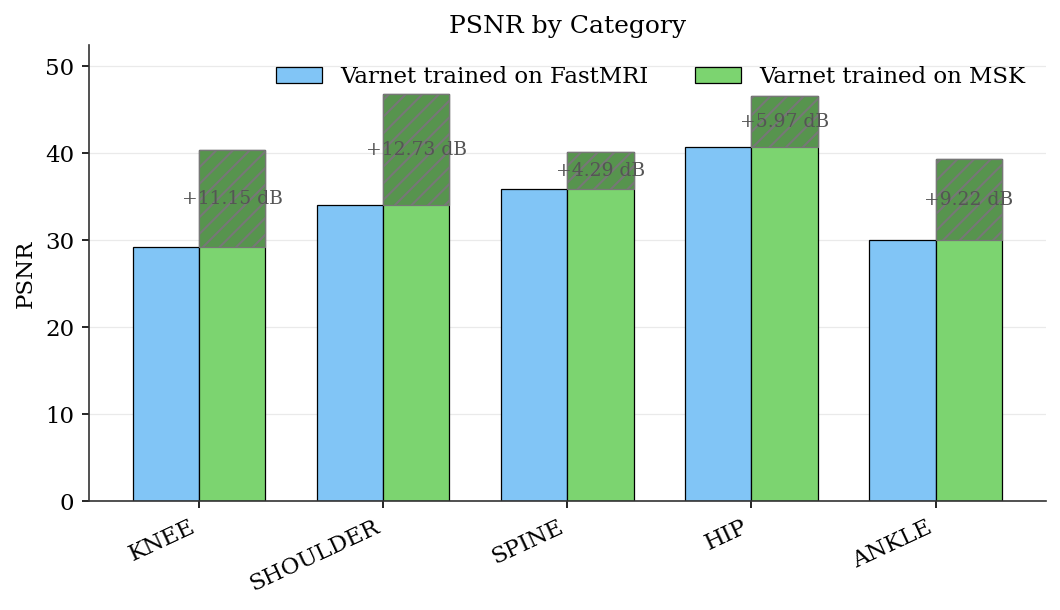

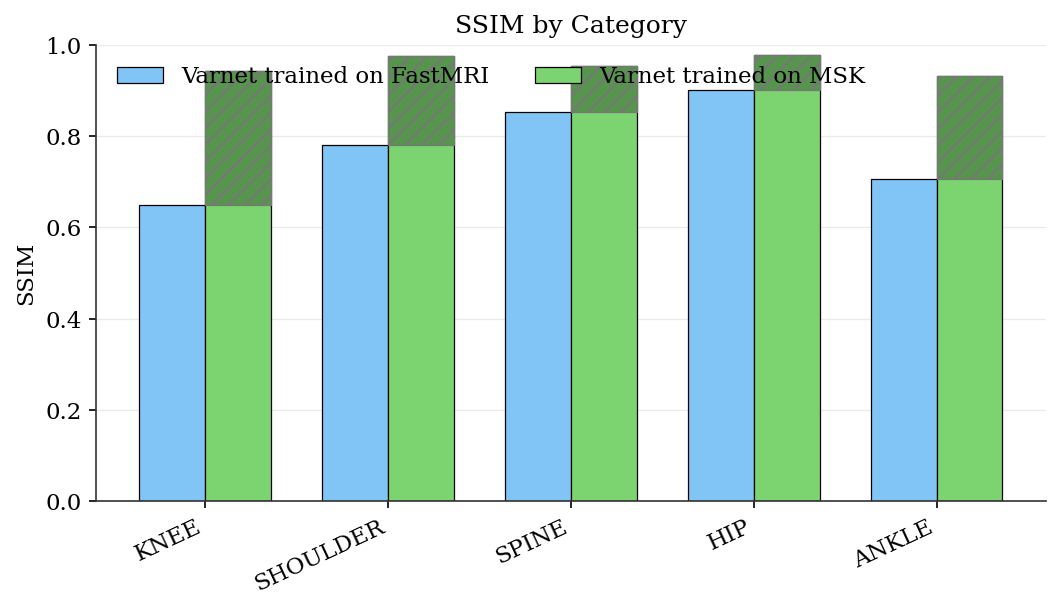

In [38]:
def shade_color(color, factor=0.7):
    r, g, b = mcolors.to_rgb(color)
    return (r * factor, g * factor, b * factor)


def plot_metric_grouped(metric, x_labels, model_order, model_values, model_labels, model_colors):
    n_models = len(model_order)
    n_groups = len(x_labels)

    values = np.array([model_values[k] for k in model_order], dtype=float)

    x = np.arange(n_groups)
    width = min(0.36, 0.8 / max(n_models, 1))
    offsets = (np.arange(n_models) - (n_models - 1) / 2) * width

    fig, ax = plt.subplots(figsize=(7.2, 4.2), dpi=150)

    for i, key in enumerate(model_order):
        ax.bar(
            x + offsets[i],
            values[i],
            width,
            color=model_colors[key],
            edgecolor='black',
            linewidth=0.6,
            label=model_labels[key],
        )

    gap_heights = np.zeros_like(values)
    gap_bottoms = np.zeros_like(values)
    for g in range(n_groups):
        vals = values[:, g]
        valid = ~np.isnan(vals)
        if valid.sum() < 2:
            continue
        valid_vals = vals[valid]
        order = np.argsort(valid_vals)
        best_val = float(valid_vals[order[-1]])
        second_val = float(valid_vals[order[-2]])
        if best_val <= second_val:
            continue
        best_idx = np.where(valid)[0][order[-1]]
        gap_heights[best_idx, g] = best_val - second_val
        gap_bottoms[best_idx, g] = second_val

    for i, key in enumerate(model_order):
        if np.any(gap_heights[i] > 0):
            ax.bar(
                x + offsets[i],
                gap_heights[i],
                width,
                bottom=gap_bottoms[i],
                color=shade_color(model_colors[key]),
                edgecolor='#777777',
                linewidth=0.6,
                hatch='///',
                zorder=3,
            )

    if metric.upper() == 'PSNR':
        for i, key in enumerate(model_order):
            for g in range(n_groups):
                gap = float(gap_heights[i, g])
                if gap > 0:
                    ax.text(
                        x[g] + offsets[i],
                        gap_bottoms[i, g] + gap / 2,
                        f"+{gap:.2f} dB",
                        ha='center',
                        va='center',
                        fontsize=9,
                        color='#555555',
                    )

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=25, ha='right')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by Category')
    ax.grid(axis='y')
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    all_vals = values[~np.isnan(values)]
    max_val = float(all_vals.max()) if all_vals.size else 1.0
    if metric.upper() == 'SSIM':
        ax.set_ylim(0.0, 1.0)
    else:
        ax.set_ylim(0.0, max_val * 1.12)

    ax.legend(frameon=False, ncol=n_models)
    plt.tight_layout()
    plt.show()


def plot_metric_compare(metric, df_a, df_b, categories):
    means_a = df_a.groupby('category')[metric].mean()
    means_b = df_b.groupby('category')[metric].mean()

    model_values = {
        'A': [means_a.get(cat, np.nan) for cat in categories],
        'B': [means_b.get(cat, np.nan) for cat in categories],
    }
    model_labels = {
        'A': results['A']['label'],
        'B': results['B']['label'],
    }
    model_colors = {
        'A': results['A']['color'],
        'B': results['B']['color'],
    }

    plot_metric_grouped(metric, categories, ['A', 'B'], model_values, model_labels, model_colors)


plot_metric_compare('PSNR', df_a_sel, df_b_sel, selected_categories)
plot_metric_compare('SSIM', df_a_sel, df_b_sel, selected_categories)


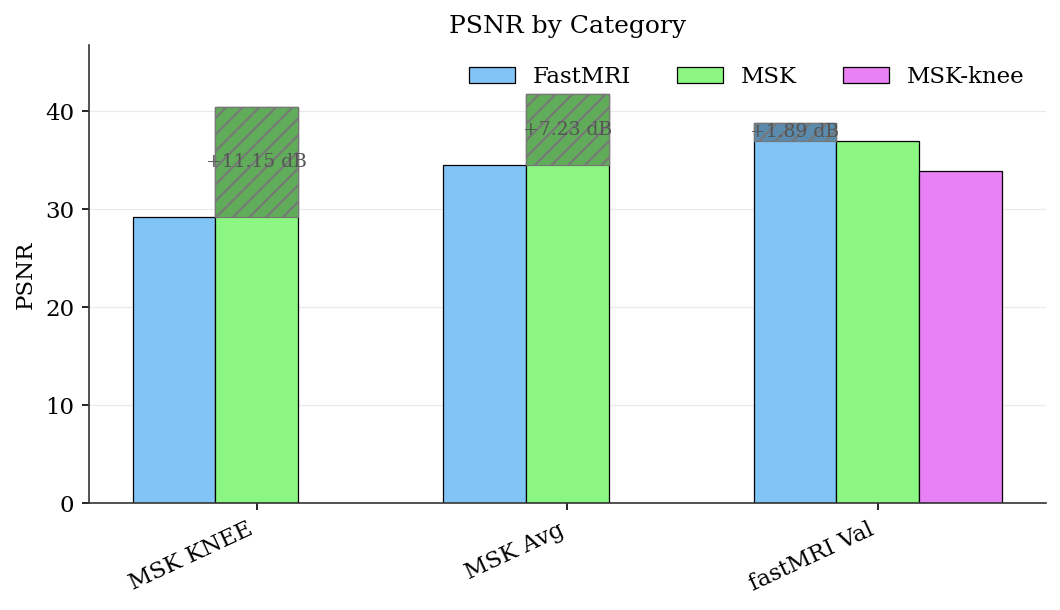

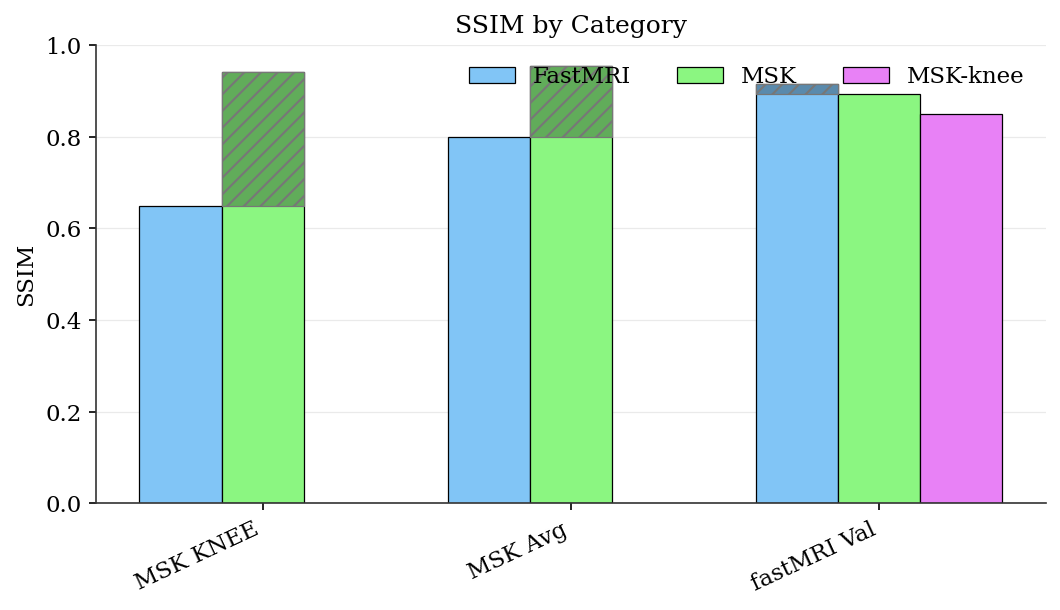

In [40]:
# --- Summary plot: KNEE (MSK), MSK average, fastMRI val ---
summary_models = {
    'M1': {
        'label': 'FastMRI',
        'msk_path': '/home/paula/msk_mri_dataset/varnet/outputs/2025/fastmri_baseline/msk_casc8_acc4',
        'fastmri_path': '/home/paula/msk_mri_dataset/varnet/outputs/2025/fastmri_baseline/fastmri_casc8_acc4',
        'color': "#81c5f6",
    },
    'M2': {
        'label': 'MSK',
        'msk_path': '/home/paula/msk_mri_dataset/varnet/outputs/2025/msk_baseline/msk_casc8_acc4',
        'fastmri_path': '/home/paula/msk_mri_dataset/varnet/outputs/2025/msk_baseline/fastmri_casc8_acc4',
        'color': "#8bf681",
    },
    'M3': {
        'label': 'MSK-knee',
        'msk_path': '/home/paula/msk_mri_dataset/varnet/outputs/2025/msk_anatomy_order-shift/msk_anatomy_knee_casc8_acc4',
        'fastmri_path': '/home/paula/msk_mri_dataset/varnet/outputs/2025/msk_anatomy_order-shift/msk_anatomy_knee_casc8_acc4',
        'color': "#e881f6",
    },
}
summary_order = ['M1', 'M2', 'M3']

summary_x = ['MSK KNEE', 'MSK Avg', 'fastMRI Val']


def load_metrics_json(results_path):
    json_path = os.path.join(results_path, 'metrics.json')
    if not os.path.exists(json_path):
        raise FileNotFoundError(f'Could not find metrics.json in {results_path}')
    with open(json_path, 'r') as f:
        return json.load(f)


def get_global_metric(metrics_json, metric):
    g = metrics_json.get('global', {}).get(metric)
    if isinstance(g, dict):
        val = g.get('mean')
    else:
        val = g
    if val is not None:
        return float(val)

    per_vol = metrics_json.get('per_volume', {})
    vals = [m.get(metric) for m in per_vol.values() if m.get(metric) is not None]
    return float(np.mean(vals)) if vals else np.nan


def build_summary_values(metric):
    model_values = {}
    summary_category_cache = {}

    for key in summary_order:
        model = summary_models[key]
        df_msk = build_df(model['msk_path'], summary_category_cache)
        df_msk_matched = df_msk[df_msk['category'].notna()]

        knee_val = df_msk_matched[df_msk_matched['category'] == 'KNEE'][metric].mean()
        msk_avg = df_msk_matched[metric].mean()

        fastmri_metrics = load_metrics_json(model['fastmri_path'])
        fastmri_val = get_global_metric(fastmri_metrics, metric)

        model_values[key] = [knee_val, msk_avg, fastmri_val]

    return model_values


summary_labels = {k: summary_models[k]['label'] for k in summary_order}
summary_colors = {k: summary_models[k]['color'] for k in summary_order}

summary_values_psnr = build_summary_values('PSNR')
plot_metric_grouped('PSNR', summary_x, summary_order, summary_values_psnr, summary_labels, summary_colors)

summary_values_ssim = build_summary_values('SSIM')
plot_metric_grouped('SSIM', summary_x, summary_order, summary_values_ssim, summary_labels, summary_colors)
